Daniel Simple Moving Avg:

In [ ]:
from Functions import *

In [2]:
def SimpleMA(df, small_window=20, long_window=50):
    result = df[['close']].copy()  # keep close column
    result['signal'] = 0

    sma = df['close'].rolling(window=small_window).mean()
    lma = df['close'].rolling(window=long_window).mean()

    result.loc[sma > lma, 'signal'] = 1
    result.loc[sma < lma, 'signal'] = -1

    return result

In [3]:
df = get_stock_data("AAPL", "2024-05-01", "2024-05-10", "Minute", 1)
a = SimpleMA(df)
print(a)

                                   close  signal
symbol timestamp                                
AAPL   2024-05-01 08:00:00+00:00  170.20       0
       2024-05-01 08:01:00+00:00  170.00       0
       2024-05-01 08:02:00+00:00  170.00       0
       2024-05-01 08:05:00+00:00  169.90       0
       2024-05-01 08:07:00+00:00  169.90       0
...                                  ...     ...
       2024-05-09 23:52:00+00:00  184.74      -1
       2024-05-09 23:53:00+00:00  184.79      -1
       2024-05-09 23:54:00+00:00  184.74      -1
       2024-05-09 23:55:00+00:00  184.73      -1
       2024-05-09 23:56:00+00:00  184.79       1

[5559 rows x 2 columns]


In [27]:
def backtest(data, initial_cash=10_000, transaction_cost=0):
    in_position = False
    cash = initial_cash
    entry_price = 0
    trade_log = []
    equity_curve = []

    for i in range(1, len(data)):
        signal = data['signal'].iloc[i]
        price = data['close'].iloc[i]
        timestamp = data.index[i]

        # Track equity at each time step
        equity_curve.append((timestamp, cash))

        if signal == 1 and not in_position:
            entry_price = price
            in_position = True
            trade_log.append({
                'timestamp': timestamp,
                'action': 'buy',
                'price': price
            })

        elif signal == -1 and in_position:
            pnl = price - entry_price
            cash += pnl
            in_position = False
            trade_log.append({
                'timestamp': timestamp,
                'action': 'sell',
                'price': price,
                'pnl': pnl,
                'cash': cash
            })

    # Final equity entry
    if len(data) > 0:
        equity_curve.append((data.index[-1], cash))

    # Convert to pandas Series
    index = [ts[1] if isinstance(ts, tuple) else ts for (ts, _) in equity_curve]
    equity_series = pd.Series(
        data=[val for (_, val) in equity_curve],
        index=pd.to_datetime(index)
    )

    return equity_series, trade_log


In [25]:
def plot_equity_curve(equity_series):
    plt.figure(figsize=(12, 6))
    plt.plot(equity_series, label='Equity Curve', linewidth=2)
    plt.title("Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


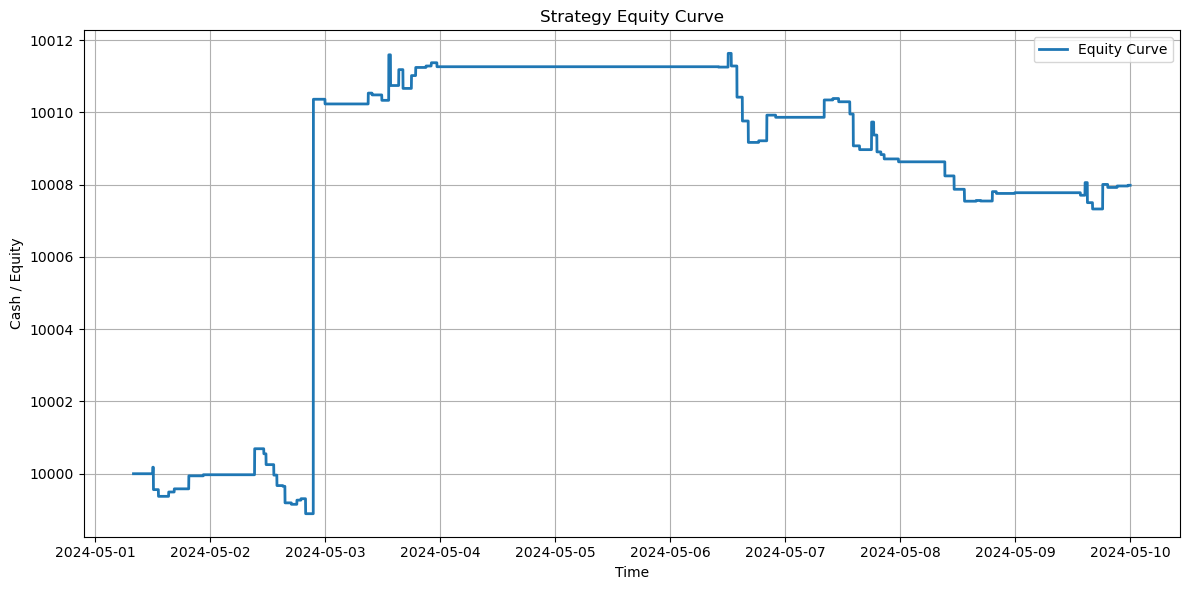

In [28]:
df = get_stock_data("AAPL", "2024-05-01", "2024-05-10", "Minute", 1)
signals = SimpleMA(df)
equity_series, trades = backtest(signals)
plot_equity_curve(equity_series)


In [ ]:
def evaluate_performance(equity_series, trade_log, initial_cash=10_000, benchmark_symbol="SPY"):
    """
    Evaluates strategy performance metrics based on equity curve and trade log.
    """
    equity_series = equity_series.sort_index().astype(float)

    if equity_series.empty or not trade_log:
        return {"error": "Insufficient data to evaluate performance."}

    final_cash = equity_series.iloc[-1]
    total_return = (final_cash - initial_cash) / initial_cash

    # Determine frequency for annualization
    index_deltas = equity_series.index.to_series().diff().dropna()
    median_delta = index_deltas.median()
    periods_per_year = {
        pd.Timedelta("1min"): 252 * 390,
        pd.Timedelta("5min"): 252 * 78,
        pd.Timedelta("15min"): 252 * 26,
        pd.Timedelta("1H"): 252 * 6.5,
        pd.Timedelta("1D"): 252
    }
    closest_freq = min(periods_per_year.keys(), key=lambda x: abs(x - median_delta))
    freq = periods_per_year[closest_freq]

    # Strategy returns
    returns = equity_series.pct_change().dropna()
    annualized_return = (1 + total_return) ** (freq / len(returns)) - 1 if not returns.empty else 0
    volatility = returns.std() * np.sqrt(freq)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(freq) if returns.std() != 0 else 0

    # Sortino ratio
    downside = returns[returns < 0]
    sortino = (returns.mean() / downside.std()) * np.sqrt(freq) if not downside.empty else 0

    # Max drawdown
    rolling_max = equity_series.cummax()
    drawdown = (equity_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # Exposure
    in_market_steps = sum(1 for t in trade_log if t['action'] == 'buy')
    exposure = in_market_steps / len(equity_series)

    # --- ALPHA/BETA using return alignment (robust) ---
    # Get SPY data
    spy_df = get_stock_data(
        benchmark_symbol,
        equity_series.index[0].strftime("%Y-%m-%d"),
        equity_series.index[-1].strftime("%Y-%m-%d"),
        timeframe_unit="Day", multiplier=1
    )

    # Compute returns
    strategy_returns = equity_series.pct_change().dropna()
    spy_returns = spy_df['close'].pct_change().dropna()

    # Drop duplicate timestamps
    strategy_returns = strategy_returns[~strategy_returns.index.duplicated()]
    spy_returns = spy_returns[~spy_returns.index.duplicated()]

    # Join on common timestamps
    returns_df = pd.concat([strategy_returns, spy_returns], axis=1, join='inner')
    returns_df.columns = ['strategy', 'spy']
    returns_df.dropna(inplace=True)

    # Compute beta and alpha
    if not returns_df.empty:
        slope, intercept, r_value, p_value, std_err = linregress(
            returns_df['spy'], returns_df['strategy']
        )
        beta = slope
        alpha = (returns_df['strategy'].mean() - beta * returns_df['spy'].mean()) * freq
    else:
        beta = np.nan
        alpha = np.nan


    # Final result
    return {
        "Final Cash": round(final_cash, 2),
        "Total Return (%)": round(total_return * 100, 2),
        "Annualized Return (%)": round(annualized_return * 100, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Sortino Ratio": round(sortino, 2),
        "Volatility (%)": round(volatility * 100, 2),
        "Max Drawdown (%)": round(max_drawdown * 100, 2),
        "Alpha vs SPY (%)": round(alpha * 100, 2) if not np.isnan(alpha) else None,
        "Beta vs SPY": round(beta, 2) if not np.isnan(beta) else None,
        "Exposure (%)": round(exposure * 100, 2),
        "Frequency Used": str(closest_freq)
    }


In [15]:
df = get_stock_data("AAPL", "2024-05-01", "2024-05-10", "Minute", 1)
signals = SimpleMA(df)
equity_series, trade_log = backtest(signals)

performance = evaluate_performance(equity_series, trade_log)
print(performance)


{'Final Cash': 10007.98, 'Total Return (%)': 0.08, 'Annualized Return (%)': 1.42, 'Sharpe Ratio': 2.82, 'Sortino Ratio': 1.81, 'Volatility (%)': 0.5, 'Max Drawdown (%)': -0.04, 'Alpha vs SPY (%)': None, 'Beta vs SPY': None, 'Exposure (%)': 1.26, 'Frequency Used': '0 days 00:01:00'}


C:\Users\narut\AppData\Local\Temp\ipykernel_5716\1849821966.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  pd.Timedelta("1H"): 252 * 6.5,


In [18]:
import pandas as pd

def evaluate_trades(trade_log):
    """
    Evaluate detailed statistics for individual trades.
    Assumes alternating buy/sell pairs and PnL only on sell actions.
    """
    if not trade_log:
        return {"error": "Trade log is empty."}

    trades = []
    current_trade = {}

    for trade in trade_log:
        # Extract plain timestamp even if it's a tuple
        ts = trade['timestamp'][1] if isinstance(trade['timestamp'], tuple) else trade['timestamp']

        if trade['action'] == 'buy':
            current_trade = {'entry_time': ts, 'entry_price': trade['price']}
        elif trade['action'] == 'sell' and current_trade:
            exit_time = ts
            exit_price = trade['price']
            pnl = trade['pnl']

            duration = (exit_time - current_trade['entry_time']).total_seconds() / 60  # minutes
            trades.append({
                'pnl': pnl,
                'duration_min': duration,
                'entry_time': current_trade['entry_time'],
                'exit_time': exit_time
            })
            current_trade = {}

    if not trades:
        return {"error": "No completed buy/sell pairs found."}

    df = pd.DataFrame(trades)

    wins = df[df['pnl'] > 0]
    losses = df[df['pnl'] < 0]

    win_rate = len(wins) / len(df)
    avg_pnl = df['pnl'].mean()
    expectancy = (win_rate * wins['pnl'].mean()) - ((1 - win_rate) * abs(losses['pnl'].mean())) if not losses.empty else wins['pnl'].mean()

    return {
        "Number of Trades": len(df),
        "Win Rate (%)": round(win_rate * 100, 2),
        "Avg PnL": round(avg_pnl, 2),
        "Best Trade": round(df['pnl'].max(), 2),
        "Worst Trade": round(df['pnl'].min(), 2),
        "Avg Win": round(wins['pnl'].mean(), 2) if not wins.empty else None,
        "Avg Loss": round(losses['pnl'].mean(), 2) if not losses.empty else None,
        "Reward:Risk Ratio": round(wins['pnl'].mean() / abs(losses['pnl'].mean()), 2)
                             if not wins.empty and not losses.empty else None,
        "Avg Duration (min)": round(df['duration_min'].mean(), 2),
        "Win Std Dev": round(wins['pnl'].std(), 2) if len(wins) > 1 else 0,
        "Loss Std Dev": round(losses['pnl'].std(), 2) if len(losses) > 1 else 0,
        "Expectancy": round(expectancy, 2)
    }


In [19]:
trade_stats = evaluate_trades(trade_log)
print(trade_stats)

{'Number of Trades': 69, 'Win Rate (%)': 42.03, 'Avg PnL': 0.12, 'Best Trade': 11.47, 'Worst Trade': -0.88, 'Avg Win': 0.68, 'Avg Loss': -0.29, 'Reward:Risk Ratio': 2.32, 'Avg Duration (min)': 68.49, 'Win Std Dev': 2.1, 'Loss Std Dev': 0.25, 'Expectancy': 0.12}
